<h1 style="text-align:center; color:green; font-size:48px;">
DHNx PROJECT - STEP 2
</h1>

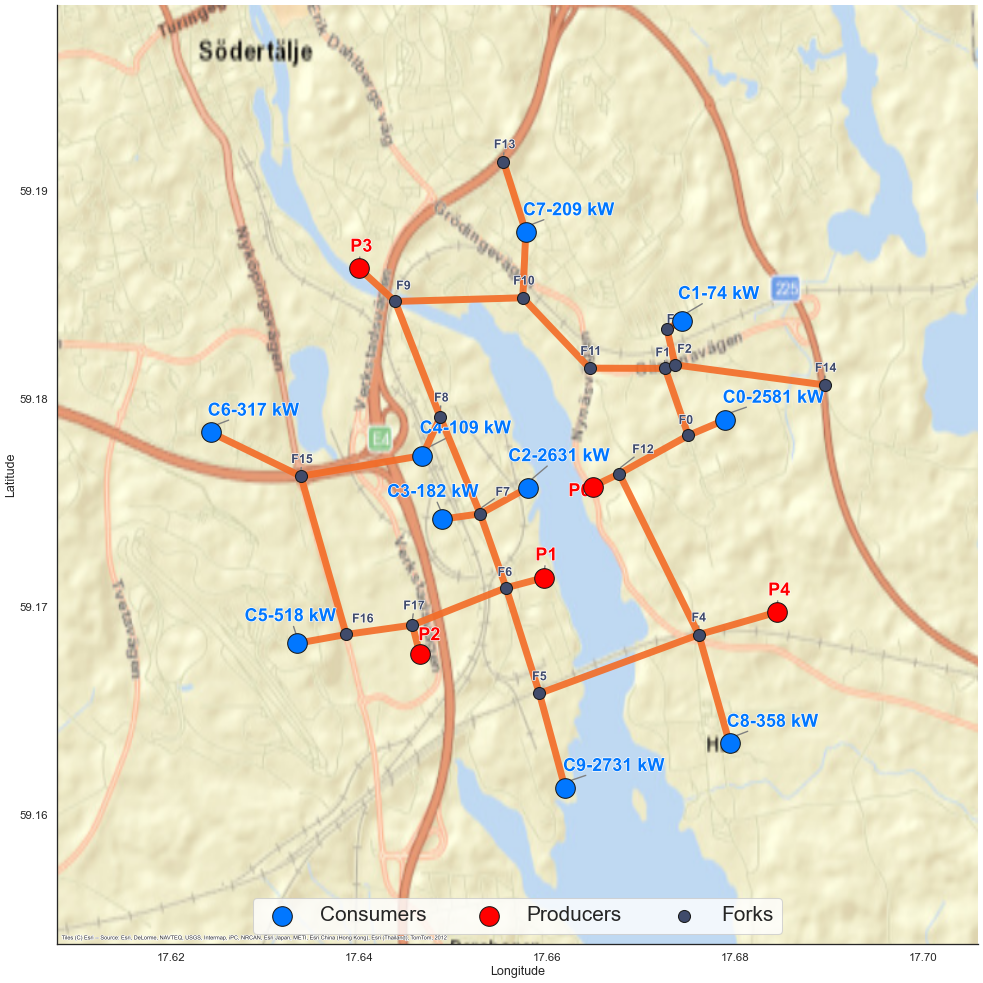

In [1]:
import matplotlib.pyplot as plt
import dhnx
import pandas as pd
import oemof.solph
from pyomo.environ import SolverFactory
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import contextily as ctx
from DHNx_gen_map import plot_dhn_map

network = dhnx.network.ThermalNetwork()
network = network.from_csv_folder(r"../2_inputs/2_step_twn_data")
invest_opt = dhnx.input_output.load_invest_options(r"../2_inputs/2_step_invest_data")

fig, ax = plot_dhn_map(network)
plt.show()




<h1 style="text-align:center; color:green; font-size:48px;">
OPTIMIZE THE NETWORK
</h1>

In [2]:
network.optimize_investment(invest_options=invest_opt,  solver='gurobi')


c:\Users\ardia\miniconda3\envs\env_P2\lib\site-packages\oemof\solph\flows\_flow.py:163: FutureWarning: For backward compatibility, the option investment overwrites the option nominal_value. Both options cannot be set at the same time.
  warn(msg, FutureWarning)
c:\Users\ardia\miniconda3\envs\env_P2\lib\site-packages\oemof\network\network\nodes.py:250: FutureWarning: Usage of oemof.network.Component is deprecated. Use oemof.network.Node instead.
  warnings.warn(


Set parameter Username
Set parameter LicenseID to value 2729760
Academic license - for non-commercial use only - expires 2026-10-30
Read LP format model from file C:\Users\ardia\AppData\Local\Temp\tmp_ymnylzu.pyomo.lp
Reading time = 0.06 seconds
x1: 11049 rows, 9797 columns, 25709 nonzeros
Gurobi Optimizer version 12.0.3 build v12.0.3rc0 (win64 - Windows 11.0 (26100.2))

CPU model: Intel(R) Core(TM) Ultra 7 155H, instruction set [SSE2|AVX|AVX2]
Thread count: 16 physical cores, 22 logical processors, using up to 22 threads

Optimize a model with 11049 rows, 9797 columns and 25709 nonzeros
Model fingerprint: 0x63a378de
Variable types: 8573 continuous, 1224 integer (1224 binary)
Coefficient statistics:
  Matrix range     [6e-05, 2e+05]
  Objective range  [1e+00, 3e+06]
  Bounds range     [1e+00, 2e+05]
  RHS range        [7e+01, 3e+03]
Presolve removed 8742 rows and 6317 columns
Presolve time: 0.03s
Presolved: 2307 rows, 3480 columns, 9864 nonzeros
Variable types: 2280 continuous, 1200 in

INFO:root:Optimization successful...
c:\Users\ardia\miniconda3\envs\env_P2\lib\site-packages\dhnx\optimization\optimization_models.py:510: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[hp_lab + '.' + 'status'] = \
c:\Users\ardia\miniconda3\envs\env_P2\lib\site-packages\dhnx\optimization\optimization_models.py:486: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[hp_lab + '.' + 'dir-1'] = df['from_node'] + '-' + df['to_node']
c:\Users\ardia\miniconda3\envs\env_P2\lib\site-packages\dhnx\optimization\optimization_models.py:487: 

      from_node      to_node hp_type     capacity  direction          costs  \
id                                                                            
0      forks-12      forks-0  DN-150  2732.131143          1  689920.510607   
1       forks-0  consumers-0  DN-150  2597.930231          1  350084.553909   
2       forks-0      forks-1   DN-25   100.297057          1  302399.705766   
3       forks-1      forks-2   DN-32    85.634747          1   46606.987263   
4       forks-2      forks-3   DN-25    83.823256          1  152764.661038   
5       forks-3  consumers-1   DN-32    76.921560          1   77304.050227   
6       forks-1     forks-11    None     0.000000          0       0.000000   
7      forks-11     forks-10    None     0.000000          0       0.000000   
8      forks-10      forks-9   DN-50   257.665519         -1  697571.619811   
9       forks-9      forks-8    None     0.000000          0       0.000000   
10      forks-8  consumers-4    None     0.000000   

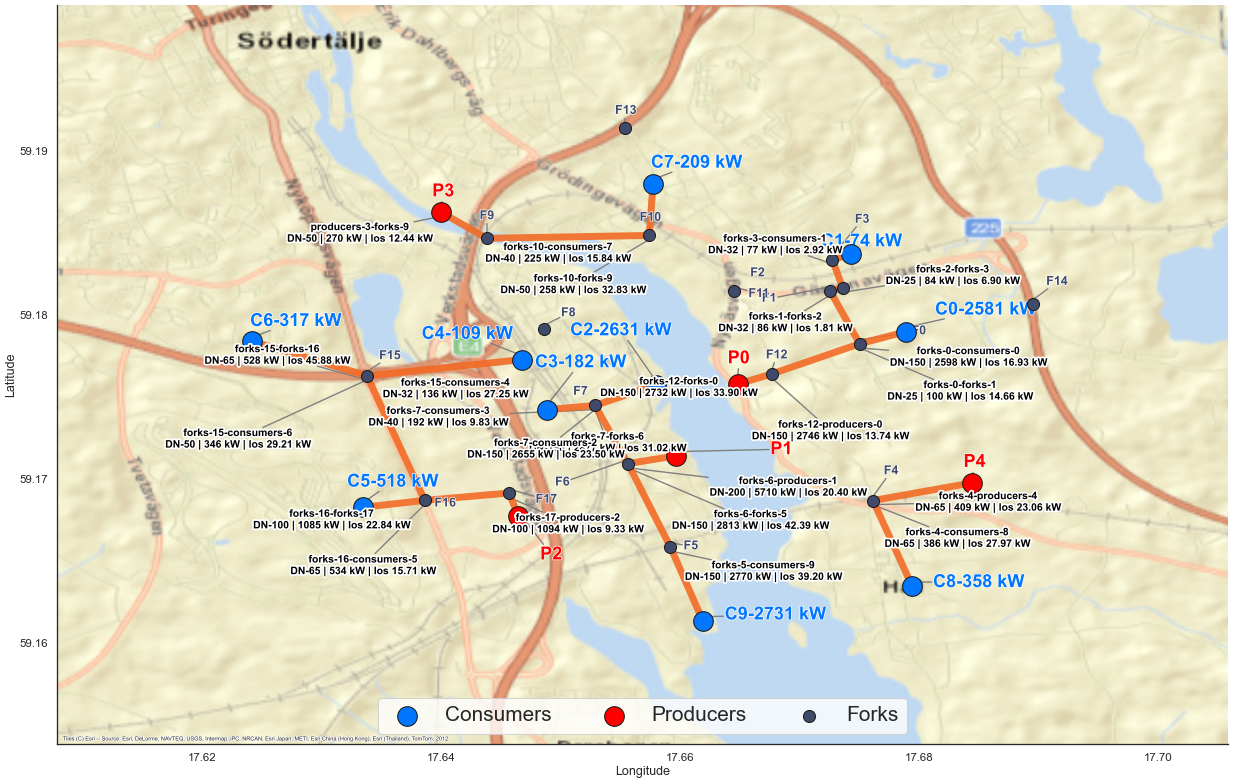

In [3]:
results_edges = network.results.optimization['components']['pipes']
print(results_edges[['from_node', 'to_node', 'hp_type', 'capacity',
                     'direction', 'costs', 'losses']])
results_edges.to_csv("../3_outputs/DHNx_step2_result.csv", index=True)

print('Objective value: ', network.results.optimization['oemof_meta']['objective'])

twn_results = network
twn_results.components['pipes'] = results_edges[results_edges['capacity'] > 0.001]
results_pipes = network.results.optimization['components']['pipes']
fig, ax = plot_dhn_map(network, results_edges=results_pipes, debug=True, figsize=(25,16),)

Number of islands: 5

=== Island summary ===
   island_id  n_pipes  total_length  max_capacity   total_costs  total_losses  \
1          2        3          1430    270.106494  1.266865e+06     61.106494   
4          5        6          3141   1094.229518  3.031021e+06    150.229518   
3          4        2          1102    409.024160  1.067473e+06     51.024160   
0          1        7          1650   2745.867942  1.898164e+06     90.867942   
2          3        6          2360   5710.338874  3.403385e+06    166.338874   

   loss_percent  
1     22.623112  
4     13.729251  
3     12.474608  
0      3.309261  
2      2.912942  

Mean island loss percent: 11.00983484530977


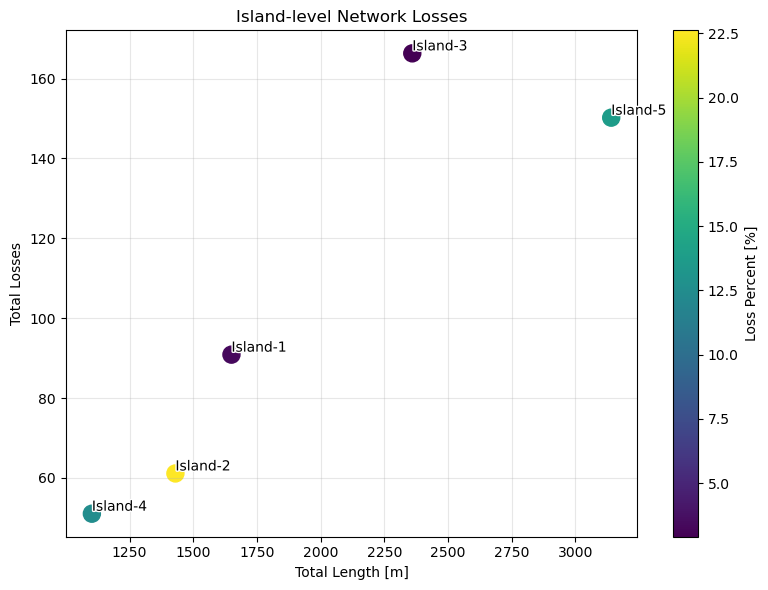

In [9]:
import pandas as pd
import numpy as np
from statistics import mean
import networkx as nx

CSV_FILE = "../3_outputs/DHNx_step2_result.csv"
OUTPUT_ISLAND_CSV = "../3_outputs/Step2_island_losses_output.csv"
OUTPUT_PIPES_CSV  = "../3_outputs/Step2_pipes_with_island.csv"

# =========================
# LOAD + CLEAN
# =========================
df = pd.read_csv(CSV_FILE)
df.columns = [c.strip() for c in df.columns]

for c in ["length", "capacity", "costs", "losses"]:
    df[c] = pd.to_numeric(df[c], errors="coerce").fillna(0.0)

df["from_node"] = df["from_node"].astype(str).str.strip()
df["to_node"]   = df["to_node"].astype(str).str.strip()

# =========================
# KEEP ONLY BUILT PIPES
# =========================
df_built = df[df["capacity"] > 0].copy()

# =========================
# ISLAND MAPPING
# =========================
G = nx.Graph()
G.add_edges_from(zip(df_built["from_node"], df_built["to_node"]))

components = list(nx.connected_components(G))
print(f"Number of islands: {len(components)}")

node_to_island = {}
for i, comp in enumerate(components, start=1):
    for node in comp:
        node_to_island[node] = i

df_built["island_id"] = df_built["from_node"].map(node_to_island)

df_built = df_built.sort_values(
    ["island_id", "from_node", "to_node", "id"]
).reset_index(drop=True)

# =========================
# AGGREGATE PER ISLAND
# =========================
island_summary = (
    df_built.groupby("island_id", as_index=False)
            .agg(
                n_pipes=("id", "count"),
                total_length=("length", "sum"),
                max_capacity=("capacity", "max"),
                total_costs=("costs", "sum"),
                total_losses=("losses", "sum"),
            )
)

island_summary["loss_percent"] = (
    100 * island_summary["total_losses"] / island_summary["max_capacity"]
)

island_summary = island_summary.sort_values(
    "loss_percent", ascending=False
)

# =========================
# PRINT CHECK
# =========================
print("\n=== Island summary ===")
print(island_summary)
print("\nMean island loss percent:", mean(island_summary["loss_percent"]))

# =========================
# EXPORT TO CSV
# =========================
island_summary.to_csv(OUTPUT_ISLAND_CSV, index=False)
df_built.to_csv(OUTPUT_PIPES_CSV, index=False)

# print(f"\n✅ Exported CSV files:")
# print(f" - {OUTPUT_ISLAND_CSV}")
# print(f" - {OUTPUT_PIPES_CSV}")

import pandas as pd
import matplotlib.pyplot as plt
import contextily as ctx
from adjustText import adjust_text
import matplotlib.patheffects as pe
# Load data
df = pd.read_csv(OUTPUT_ISLAND_CSV)

text_objs = []   # all text for adjustText
text_pe = [pe.withStroke(linewidth=2, foreground="white")]
# Ensure numeric
cols = ["total_length", "total_losses", "loss_percent"]
df[cols] = df[cols].apply(pd.to_numeric, errors="coerce")

# Plot
plt.figure(figsize=(8, 6))
sc = plt.scatter(
    df["total_length"],
    df["total_losses"],
    c=df["loss_percent"],
    s=150,
    cmap="viridis"
)

plt.xlabel("Total Length [m]")
plt.ylabel("Total Losses")
plt.title("Island-level Network Losses")

# Colorbar
cbar = plt.colorbar(sc)
cbar.set_label("Loss Percent [%]")

# Annotate island IDs
for _, row in df.iterrows():
    plt.text(
        row["total_length"],
        row["total_losses"],
        f"Island-{int(row['island_id'])}",
        fontsize=10,
        ha="left",
        va="bottom",
        path_effects=text_pe,
        zorder=15,
    )
    # Automatically adjust labels to avoid overlap
    adjust_text(
        text_objs,
        ax=plt.text,
        arrowprops=dict(arrowstyle="-", lw=2, color="gray", alpha=1),
        only_move={"text": "xy"},
    )

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
